# 🤖 Production-Grade Multi-Agent Coding System
### Built with LangGraph, OpenRouter, and MCP (Filesystem, Terminal, & Ripgrep)

This notebook implements a scalable, production-grade **Multi-Agent Coding Architecture** designed to tackle complex software engineering tasks on large codebases.

---

### 🏛️ System Architecture

```
                            ┌──────────────────────┐
                            │   Supervisor Agent   │
                            │  (Orchestrator &     │
                            │   HITL Gatekeeper)   │
                            └──────────┬───────────┘
                                       │ (Command(goto=...))
         ┌───────────────┬─────────────┼──────────────┬──────────────┐
         ▼               ▼             ▼              ▼              ▼
  ┌──────────────┐ ┌──────────┐ ┌─────────────┐ ┌───────────┐ ┌────────────┐
  │   Analyzer   │ │ Planner  │ │Task Creator │ │  Coding   │ │  QA Agent  │
  │    Agent     │ │  Agent   │ │    Agent    │ │   Agent   │ │(Validation)│
  └──────────────┘ └──────────┘ └─────────────┘ └───────────┘ └────────────┘
```

#### 1. Supervisor Agent (Orchestrator)
- Dynamically decides which agent to invoke based on progress, errors, and task queue.
- Enforces HITL (Human-in-the-Loop) approval checkpoints before modifying code.
- Handles loop limits, retries, and failure escalation.

#### 2. Analyzer Agent
- Deeply analyzes project code using keyword/symbol/ripgrep search & file tree metadata.
- Minimizes token context by performing partial file reads (e.g. L1-L200).
- Produces `analyzer_insights`.

#### 3. Planner Agent
- Consumes `analyzer_insights` and formulates a multi-phase `implementation_plan`.
- Identifies dependencies, risks, assumptions, and target modules.

#### 4. Task Creator Agent
- Converts the implementation plan into atomic, executable coding tasks with acceptance criteria.

#### 5. Coding Agent
- Executes tasks one at a time using MCP Filesystem & Terminal tools.
- Applies clean coding standards and updates project state after task completion.

#### 6. QA Agent
- Performs multi-stage validation: Linting -> Compilation/Build -> Tests -> Functional Acceptance.
- Re-routes control back to Coder/Planner on failure.

---

## 1. Setup & Environment Initialization

In [85]:
import sys
import os
import shutil
import asyncio
import json
import re
from typing import TypedDict, Annotated, Any, List, Dict, Optional, Literal
import nest_asyncio
from dotenv import load_dotenv

# Restore sys.stderr for Windows subprocess file descriptor support in Jupyter
if sys.platform == "win32":
    sys.stderr = sys.__stderr__

# Patch nested event loops for Jupyter Notebook cell compatibility
nest_asyncio.apply()

# Load API keys from environment (.env)
load_dotenv()

api_key = os.getenv("OPENROUTER_API_KEY")
if not api_key:
    print("⚠️ OPENROUTER_API_KEY not found! Please ensure it is set in your .env file.")
else:
    print("✅ Environment initialized. OPENROUTER_API_KEY loaded.")

✅ Environment initialized. OPENROUTER_API_KEY loaded.


## 2. Initialize MCP Servers (Filesystem, Terminal, Search) & Load Tools

In [86]:
from langchain_mcp_adapters.client import MultiServerMCPClient

# Target directory for tool access
target_dir = os.path.abspath(".")
npx_cmd = shutil.which("npx") or "npx.cmd"

print(f"Target directory for MCP Servers: {target_dir}")
print(f"Using resolved npx executable: {npx_cmd}")

# Initialize MCP client with Filesystem, Terminal, and Ripgrep Search servers
mcp_client = MultiServerMCPClient({
    "filesystem": {
        "command": npx_cmd,
        "args": ["-y", "@modelcontextprotocol/server-filesystem", target_dir],
        "transport": "stdio"
    },
    "terminal": {
        "command": npx_cmd,
        "args": ["-y", "bash-mcp", target_dir],
        "transport": "stdio"
    },
    "search": {
        "command": npx_cmd,
        "args": ["-y", "mcp-ripgrep@latest", target_dir],
        "transport": "stdio"
    }
})

# Fetch all tools asynchronously
mcp_tools = await mcp_client.get_tools()

# Group tools by server type for clean assignment to agents
terminal_tool_names = {"run", "run_background", "kill_background", "list_background"}
search_tool_names = {"search", "advanced-search", "count-matches", "list-files", "list-file-types"}

fs_tools = [t for t in mcp_tools if t.name not in terminal_tool_names and t.name not in search_tool_names]
term_tools = [t for t in mcp_tools if t.name in terminal_tool_names]
search_tools = [t for t in mcp_tools if t.name in search_tool_names]

print(f"\n✅ Successfully loaded {len(mcp_tools)} total MCP tools:")
print(f"  • 📁 Filesystem tools ({len(fs_tools)}): {[t.name for t in fs_tools]}")
print(f"  • 🔍 Search tools ({len(search_tools)}): {[t.name for t in search_tools]}")
print(f"  • 💻 Terminal tools ({len(term_tools)}): {[t.name for t in term_tools]}")

Target directory for MCP Servers: d:\Ai Content\Agentic AI
Using resolved npx executable: C:\Program Files\nodejs\npx.CMD

✅ Successfully loaded 23 total MCP tools:
  • 📁 Filesystem tools (14): ['read_file', 'read_text_file', 'read_media_file', 'read_multiple_files', 'write_file', 'edit_file', 'create_directory', 'list_directory', 'list_directory_with_sizes', 'directory_tree', 'move_file', 'search_files', 'get_file_info', 'list_allowed_directories']
  • 🔍 Search tools (5): ['search', 'advanced-search', 'count-matches', 'list-files', 'list-file-types']
  • 💻 Terminal tools (4): ['run', 'run_background', 'kill_background', 'list_background']


## 3. Setup OpenRouter LLM (`ChatOpenRouter`)

In [87]:
from langchain_openrouter import ChatOpenRouter

from langchain_mistralai import ChatMistralAI

llm = ChatMistralAI(model="mistral-large-latest")

# OpenRouter model selection
MODEL_NAME = os.getenv("MODEL_NAME", "nvidia/nemotron-3-ultra-550b-a55b:free")

# llm = ChatOpenRouter(
#     model_name=MODEL_NAME,
#     openrouter_api_key=os.getenv("OPENROUTER_API_KEY"),
#     temperature=0.2
# )

print(f"✅ OpenRouter LLM initialized with model: {MODEL_NAME}")

✅ OpenRouter LLM initialized with model: nvidia/nemotron-3-ultra-550b-a55b:free


## 4. State Management Architecture

We implement a **hybrid state architecture**:
- **Shared Global State**: Maintains end-to-end communication, task queues, plans, code changes, and QA reports.
- **Agent-Local State**: Kept as transient local variables inside each sub-agent node function to prevent polluting global context.

In [88]:
from langchain_core.messages import BaseMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver

# Definition of Shared Global State across the entire graph
class GlobalState(TypedDict):
    # --- Core Messaging & Goal ---
    messages: Annotated[list[BaseMessage], add_messages]
    goal: str
    
    # --- Orchestration & Status ---
    current_agent: str                     # "supervisor" | "analyzer" | "planner" | "task_creator" | "coder" | "qa"
    execution_status: str                  # "running" | "completed" | "failed" | "awaiting_approval"
    execution_history: list[dict]          # History log of agent steps
    iteration_count: int                   # Safety loop counter
    max_iterations: int                    # Maximum allowed iterations (default 25)
    supervisor_reasoning: str              # Explanation from Supervisor for routing decision
    
    # --- Agent Outputs ---
    folder_tree: str                       # Workspace directory structure snapshot
    analyzer_insights: str                 # Insights from Analyzer Agent
    implementation_plan: str               # Strategic plan from Planner Agent
    tasks: list[dict]                      # All task dicts created by Task Creator
    completed_tasks: list[dict]            # Tasks successfully completed and verified
    pending_tasks: list[dict]              # Tasks waiting to be executed
    failed_tasks: list[dict]               # Tasks that failed QA validation
    current_task: Optional[dict]           # Active task currently being worked on by Coder
    
    # --- Code Modifications & Tool Logs ---
    files_changed: list[str]               # Tracked files modified during the run
    tool_results: list[dict]               # Recent tool call outputs (rolling log)
    
    # --- QA & Validation ---
    qa_report: str                         # Validation report from QA Agent
    qa_pass: bool                          # True if current task passed validation
    
    # --- Error Recovery ---
    error_log: list[dict]                  # Log of errors encountered
    retry_count: int                       # Retry attempts for active task
    max_retries: int                       # Max retries allowed per task (default 3)

print("✅ GlobalState schema defined successfully.")

✅ GlobalState schema defined successfully.


## 5. System Prompts Definition

In [89]:
SUPERVISOR_SYSTEM_PROMPT = """You are the Lead Technical Supervisor orchestrating a multi-agent AI coding system.
Your job is to inspect the user goal and system state, then select EXACTLY ONE next sub-agent to invoke.

Available Sub-Agents:
1. 'analyzer': Deeply inspects code structure, searches symbols/keywords, lists files/directories, and produces codebase insights.
2. 'planner': Consumes codebase insights to create a detailed multi-phase implementation plan.
3. 'task_creator': Breaks down the implementation plan into atomic, executable coding tasks.
4. 'coder': Executes a single coding task using file edit & shell tools.
5. 'qa': Performs validation (linting, tests, build, functional checks) on completed code tasks.
6. 'FINISH': Called when the request is fully satisfied or no further work is required.

Core Routing Principles:
* DO NOT run every agent sequentially by default. Choose ONLY the minimum required agents to fulfill the goal.
* If the request is ONLY to list files, view directory structure, search code, or answer questions -> choose 'analyzer'. Once analyzer completes its report, choose 'FINISH'. Do NOT invoke planner, task_creator, coder, or qa!
* If the request is ONLY to run tests or validate code -> choose 'qa' directly (or 'planner' first only if test setup planning is needed).
* If code changes/fixes/features are needed -> route through 'analyzer' (if context missing) -> 'planner' -> 'task_creator' -> 'coder' -> 'qa'.
* If all tasks are completed and verified -> choose 'FINISH'.

OUTPUT FORMAT REQUIREMENT:
You MUST respond ONLY with a JSON block formatted as follows:
```json
{
  "next_agent": "analyzer" | "planner" | "task_creator" | "coder" | "qa" | "FINISH",
  "reasoning": "Short 1-sentence rationale for this decision."
}
```
"""

ANALYZER_SYSTEM_PROMPT = """You are an expert Software Architecture Analyzer.
Your goal is to inspect the codebase to answer the user's request efficiently with minimal token usage.

Guidelines:
- Use ripgrep search (`search` / `advanced-search`) or file list tools to find relevant symbols, functions, and imports.
- Do NOT read full files if they are large; use line ranges (e.g. read lines 1-150) or target specific functions.
- Provide a structured summary under 'ANALYSIS INSIGHTS' containing:
  1. Workspace Directory Structure
  2. Relevant Files & Modules (with line range references)
  3. Key Code Dependencies & Import Relations
  4. Architectural Impact & Implementation Recommendations
"""

PLANNER_SYSTEM_PROMPT = """You are a Lead Software Architect.
Your goal is to produce a detailed, production-grade Implementation Plan based on the user's goal and Codebase Insights.

Structure your response under 'IMPLEMENTATION PLAN':
## Objective & Scope
## Architectural Strategy
## Implementation Phases
### Phase 1: ...
### Phase 2: ...
## Affected Files & Modules
## Risks, Dependencies & Assumptions
"""

TASK_CREATOR_SYSTEM_PROMPT = """You are a Senior Project Manager & Agile Lead.
Your goal is to convert the Implementation Plan into a JSON array of executable, atomic coding tasks.

Output MUST contain a JSON block formatted as follows:
```json
[
  {
    "id": "task_1",
    "objective": "Short objective title",
    "description": "Detailed step-by-step technical instructions for the Coder",
    "affected_files": ["path/to/file.py"],
    "dependencies": [],
    "acceptance_criteria": ["Criterion 1", "Criterion 2"],
    "priority": 1,
    "status": "pending"
  }
]
```
"""

CODING_AGENT_SYSTEM_PROMPT = """You are a Senior Software Engineer.
Your goal is to execute the active task accurately using available filesystem and terminal tools.

Guidelines:
- Execute ONLY the assigned task.
- Maintain high code quality, preserve existing style, formatting, and docstrings.
- Minimize unnecessary file edits.
- Verify edits after writing.
"""

QA_AGENT_SYSTEM_PROMPT = """You are a Lead QA & Test Automation Engineer.
Your goal is to validate the completed code changes in stages:
1. Linting & Syntax check
2. Compilation / Build verification
3. Test execution (if tests exist)
4. Functional acceptance verification

Produce a structured QA report and clearly state at the end:
QA VERDICT: PASS  (or QA VERDICT: FAIL)
If FAIL, specify exact error details and required fixes.
"""

print("✅ System prompts defined successfully.")

✅ System prompts defined successfully.


## 6. Helper Functions & Utility Tools

In [90]:
def extract_json_array(text: str) -> list[dict]:
    """Extract JSON array block from text response."""
    match = re.search(r'```json\s*(\[.*?\])\s*```', text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(1))
        except Exception:
            pass
    # Fallback to direct json parse
    try:
        start = text.find('[')
        end = text.rfind(']') + 1
        if start != -1 and end != 0:
            return json.loads(text[start:end])
    except Exception:
        pass
    return []

def format_task_summary(tasks: list[dict]) -> str:
    """Format task list into readable Markdown summary."""
    if not tasks:
        return "No tasks created yet."
    lines = []
    for t in tasks:
        status_icon = "✅" if t.get("status") == "completed" else ("❌" if t.get("status") == "failed" else "⏳")
        lines.append(f"{status_icon} **{t.get('id')}**: {t.get('objective')} (Priority: {t.get('priority')})")
    return "\n".join(lines)

print("✅ Utility functions defined.")

✅ Utility functions defined.


## 7. Analyzer Agent Node

Inspects codebase via MCP search & filesystem tools to produce token-efficient codebase insights.

In [91]:
from langgraph.prebuilt import create_react_agent

async def analyzer_agent_node(state: GlobalState) -> Command[Literal["supervisor"]]:
    print("\n🔍 [Analyzer Agent] Analyzing codebase structure and relevant modules...")
    
    # Combine search + filesystem tools for analysis
    analyzer_tools = fs_tools + search_tools
    
    # Formulate internal agent prompt
    prompt = f"""User Goal: {state['goal']}

Task: Inspect the repository using search tools and directory tree. Identify files related to the goal and summarize key imports, functions, and recommendations for implementation.
"""
    
    # ReAct tool-calling agent for analysis
    agent = create_react_agent(llm, analyzer_tools, prompt=ANALYZER_SYSTEM_PROMPT)
    res = await agent.ainvoke({"messages": [("user", prompt)]})
    
    insights = res["messages"][-1].content
    print("✅ [Analyzer Agent] Analysis complete.")
    
    # Log history & update global state
    history_entry = {"agent": "analyzer", "summary": "Codebase analysis completed", "timestamp": os.times().elapsed}
    history = state.get("execution_history", []) + [history_entry]
    
    return Command(
        goto="supervisor",
        update={
            "analyzer_insights": insights,
            "execution_history": history,
            "current_agent": "analyzer"
        }
    )

print("✅ Analyzer Agent node registered.")

✅ Analyzer Agent node registered.


## 8. Planner Agent Node

Consumes codebase insights to create a detailed multi-phase implementation plan.

In [92]:
async def planner_agent_node(state: GlobalState) -> Command[Literal["supervisor"]]:
    print("\n📋 [Planner Agent] Generating multi-phase implementation plan...")
    
    prompt = f"""User Goal:
{state['goal']}

Analyzer Codebase Insights:
{state.get('analyzer_insights', 'No prior insights')}

Formulate a structured, production-grade Implementation Plan covering architectural strategy, implementation phases, affected files, and risks.
"""
    
    messages = [("system", PLANNER_SYSTEM_PROMPT), ("user", prompt)]
    res = await llm.ainvoke(messages)
    plan = res.content
    
    print("✅ [Planner Agent] Implementation plan created.")
    
    history_entry = {"agent": "planner", "summary": "Implementation plan generated", "timestamp": os.times().elapsed}
    history = state.get("execution_history", []) + [history_entry]
    
    return Command(
        goto="supervisor",
        update={
            "implementation_plan": plan,
            "execution_history": history,
            "current_agent": "planner"
        }
    )

print("✅ Planner Agent node registered.")

✅ Planner Agent node registered.


## 9. Task Creator Agent Node

Breaks down the implementation plan into atomic, executable task dictionaries.

In [93]:
async def task_creator_agent_node(state: GlobalState) -> Command[Literal["supervisor"]]:
    print("\n⚙️ [Task Creator Agent] Decomposing implementation plan into atomic tasks...")
    
    prompt = f"""Implementation Plan:
{state.get('implementation_plan', '')}

Convert this plan into a JSON array of executable tasks following the required JSON schema.
"""
    
    messages = [("system", TASK_CREATOR_SYSTEM_PROMPT), ("user", prompt)]
    res = await llm.ainvoke(messages)
    
    parsed_tasks = extract_json_array(res.content)
    if not parsed_tasks:
        # Fallback task if JSON parsing fails
        parsed_tasks = [{
            "id": "task_1",
            "objective": "Execute implementation plan",
            "description": state.get('implementation_plan', 'Execute overall plan'),
            "affected_files": [],
            "dependencies": [],
            "acceptance_criteria": ["Goal achieved"],
            "priority": 1,
            "status": "pending"
        }]
    
    print(f"✅ [Task Creator Agent] Created {len(parsed_tasks)} atomic tasks.")
    
    history_entry = {"agent": "task_creator", "summary": f"Created {len(parsed_tasks)} tasks", "timestamp": os.times().elapsed}
    history = state.get("execution_history", []) + [history_entry]
    
    return Command(
        goto="supervisor",
        update={
            "tasks": parsed_tasks,
            "pending_tasks": parsed_tasks,
            "completed_tasks": [],
            "failed_tasks": [],
            "execution_history": history,
            "current_agent": "task_creator"
        }
    )

print("✅ Task Creator Agent node registered.")

✅ Task Creator Agent node registered.


## 10. Coding Agent Node

Executes assigned tasks one at a time using MCP Filesystem and Terminal tools.

In [94]:
async def coding_agent_node(state: GlobalState) -> Command[Literal["supervisor"]]:
    current_task = state.get("current_task")
    if not current_task:
        pending = state.get("pending_tasks", [])
        if pending:
            current_task = pending[0]
        else:
            return Command(goto="supervisor", update={"current_agent": "coder"})
            
    print(f"\n💻 [Coding Agent] Executing Task: {current_task.get('id')} - {current_task.get('objective')}...")
    
    # Combine filesystem + terminal tools for code execution & file writing
    coder_tools = fs_tools + term_tools
    
    prompt = f"""Assigned Task:
ID: {current_task.get('id')}
Objective: {current_task.get('objective')}
Description: {current_task.get('description')}
Affected Files: {current_task.get('affected_files')}
Acceptance Criteria: {current_task.get('acceptance_criteria')}

Previous QA Report (if retrying): {state.get('qa_report', 'None')}

Execute the task using your tools. Edit files accurately and verify your changes.
"""
    
    agent = create_react_agent(llm, coder_tools, prompt=CODING_AGENT_SYSTEM_PROMPT)
    res = await agent.ainvoke({"messages": [("user", prompt)]})
    
    response_content = res["messages"][-1].content
    print(f"✅ [Coding Agent] Completed task execution for {current_task.get('id')}.")
    
    # Update task status and files changed list
    affected = current_task.get('affected_files', [])
    all_changed = list(set(state.get("files_changed", []) + affected))
    
    history_entry = {"agent": "coder", "summary": f"Executed task {current_task.get('id')}", "timestamp": os.times().elapsed}
    history = state.get("execution_history", []) + [history_entry]
    
    return Command(
        goto="supervisor",
        update={
            "current_task": current_task,
            "files_changed": all_changed,
            "execution_history": history,
            "current_agent": "coder"
        }
    )

print("✅ Coding Agent node registered.")

✅ Coding Agent node registered.


## 11. QA Agent Node

Validates code changes in stages (Syntax/Build/Tests/Acceptance) using Terminal & Filesystem tools.

In [95]:
async def qa_agent_node(state: GlobalState) -> Command[Literal["supervisor"]]:
    current_task = state.get("current_task", {})
    print(f"\n🧪 [QA Agent] Validating implementation for task: {current_task.get('id', 'general')}...")
    
    qa_tools = fs_tools + term_tools
    
    prompt = f"""Task to Validate:
ID: {current_task.get('id')}
Objective: {current_task.get('objective')}
Acceptance Criteria: {current_task.get('acceptance_criteria')}
Modified Files: {state.get('files_changed', [])}

Validation Instructions:
1. Check file syntax and contents using read tools or terminal python execution.
2. Run tests or python validation commands using the terminal `run` tool if relevant.
3. Produce a structured QA report.
4. End with: 'QA VERDICT: PASS' or 'QA VERDICT: FAIL'.
"""
    
    agent = create_react_agent(llm, qa_tools, prompt=QA_AGENT_SYSTEM_PROMPT)
    res = await agent.ainvoke({"messages": [("user", prompt)]})
    
    report = res["messages"][-1].content
    qa_pass = "QA VERDICT: PASS" in report or "PASS" in report.upper()
    
    # Update task queues based on QA verdict
    pending = state.get("pending_tasks", [])
    completed = state.get("completed_tasks", [])
    failed = state.get("failed_tasks", [])
    
    if qa_pass:
        print(f"✅ [QA Agent] Task {current_task.get('id')} PASSED validation.")
        if current_task in pending:
            pending.remove(current_task)
        current_task["status"] = "completed"
        completed.append(current_task)
        new_current_task = None
        retry_count = 0
    else:
        print(f"❌ [QA Agent] Task {current_task.get('id')} FAILED validation.")
        current_task["status"] = "failed"
        if current_task not in failed:
            failed.append(current_task)
        new_current_task = current_task
        retry_count = state.get("retry_count", 0) + 1
    
    history_entry = {"agent": "qa", "verdict": "PASS" if qa_pass else "FAIL", "timestamp": os.times().elapsed}
    history = state.get("execution_history", []) + [history_entry]
    
    return Command(
        goto="supervisor",
        update={
            "qa_report": report,
            "qa_pass": qa_pass,
            "pending_tasks": pending,
            "completed_tasks": completed,
            "failed_tasks": failed,
            "current_task": new_current_task,
            "retry_count": retry_count,
            "execution_history": history,
            "current_agent": "qa"
        }
    )

print("✅ QA Agent node registered.")

✅ QA Agent node registered.


## 12. Supervisor Agent Node & HITL Gatekeeper

Orchestrates routing, loop iteration limits, retries, and Human-in-the-Loop (`interrupt()`) approval checkpoints.

In [97]:
async def supervisor_agent_node(state: GlobalState) -> Command[Literal["analyzer", "planner", "task_creator", "coder", "qa", "__end__"]]:
    # Safety Iteration Counter
    iterations = state.get("iteration_count", 0) + 1
    max_iter = state.get("max_iterations", 25)
    
    print(f"\n👑 [Supervisor Agent] Step {iterations}/{max_iter} — Orchestrating workflow...")
    
    if iterations > max_iter:
        print("⚠️ [Supervisor Agent] Maximum iteration limit reached. Terminating workflow.")
        return Command(goto=END, update={"execution_status": "timeout", "iteration_count": iterations})
    
    # --- 1. HITL CHECKPOINT: Implementation Plan Approval ---
    if state.get("implementation_plan") and state.get("tasks") and state.get("execution_status") not in ["approved", "approved_code_edit"]:
        if state.get("current_agent") in ["planner", "task_creator"]:
            print("\n🛑 [HITL Checkpoint] Implementation plan ready. Requesting user approval...")
            decision = interrupt({
                "type": "plan_approval",
                "plan": state.get("implementation_plan"),
                "tasks": state.get("tasks"),
                "instruction": "Review the implementation plan and tasks. Respond with {'approved': True} to proceed or {'approved': False, 'feedback': '...'} to request revisions."
            })
            
            if not decision.get("approved", False):
                feedback = decision.get("feedback", "Plan rejected by user.")
                print(f"⚠️ Plan feedback received: {feedback}. Routing back to Planner Agent...")
                return Command(
                    goto="planner",
                    update={
                        "goal": state["goal"] + f"\nUser Feedback: {feedback}",
                        "implementation_plan": "",
                        "tasks": [],
                        "pending_tasks": [],
                        "iteration_count": iterations
                    }
                )
            else:
                print("✅ [HITL Checkpoint] Plan APPROVED by user.")
                state["execution_status"] = "approved"

    # --- 2. LLM-DRIVEN INTELLIGENT ROUTING ---
    current_agent = state.get("current_agent", "START")
    analyzer_insights = "YES" if state.get("analyzer_insights") else "NO"
    plan_status = "YES" if state.get("implementation_plan") else "NO"
    tasks_count = len(state.get("tasks", []))
    pending_tasks = state.get("pending_tasks", [])
    completed_tasks = state.get("completed_tasks", [])
    qa_pass = state.get("qa_pass", False)
    qa_report_exists = "YES" if state.get("qa_report") else "NO"

    prompt = f"""User Goal: {state['goal']}

Current Execution State:
- Previous Agent Executed: {current_agent}
- Codebase Analysis Insights Available: {analyzer_insights}
- Implementation Plan Available: {plan_status}
- Tasks Status: {tasks_count} total tasks ({len(pending_tasks)} pending, {len(completed_tasks)} completed)
- Active Task: {state.get('current_task', {}).get('id') if state.get('current_task') else 'None'}
- Latest QA Report Available: {qa_report_exists} (Pass Status: {qa_pass})
- Current Retry Count: {state.get('retry_count', 0)}

Select the next agent to invoke: 'analyzer', 'planner', 'task_creator', 'coder', 'qa', or 'FINISH'."""

    messages = [("system", SUPERVISOR_SYSTEM_PROMPT), ("user", prompt)]
    res = await llm.ainvoke(messages)
    
    next_agent = "FINISH"
    reasoning = "Routing decision"

    # Parse JSON from LLM response
    try:
        match = re.search(r'```json\s*(\{.*?\})\s*```', res.content, re.DOTALL)
        if match:
            data = json.loads(match.group(1))
        else:
            start = res.content.find('{')
            end = res.content.rfind('}') + 1
            if start != -1 and end != 0:
                data = json.loads(res.content[start:end])
            else:
                data = {}
        next_agent = data.get("next_agent", "FINISH")
        reasoning = data.get("reasoning", "")
    except Exception:
        content_lower = res.content.lower()
        if "analyzer" in content_lower:
            next_agent = "analyzer"
        elif "planner" in content_lower:
            next_agent = "planner"
        elif "task_creator" in content_lower:
            next_agent = "task_creator"
        elif "coder" in content_lower:
            next_agent = "coder"
        elif "qa" in content_lower:
            next_agent = "qa"
        else:
            next_agent = "FINISH"
        reasoning = res.content[:100]

    print(f"👑 [Supervisor Agent] Selected Next Agent: '{next_agent.upper()}' | Rationale: {reasoning}")

    # --- 3. HITL CHECKPOINT: Sensitive Code Modification Approval ---
    if next_agent == "coder" and state.get("execution_status") != "approved_code_edit":
        task_to_run = state.get("current_task") or (pending_tasks[0] if pending_tasks else {})
        print(f"\n🛑 [HITL Checkpoint] Sensitive code modifications for task '{task_to_run.get('id', 'task')}'. Requesting approval...")
        decision = interrupt({
            "type": "code_execution_approval",
            "task": task_to_run,
            "instruction": f"Approval requested to perform code modifications for task '{task_to_run.get('objective', '')}'. Respond with {{'approved': True}} to proceed."
        })
        if not decision.get("approved", False):
            feedback = decision.get("feedback", "User rejected code changes.")

            return Command(
                goto="planner",
                update={
                    "goal": state["goal"] + f"\nUser Feedback: {feedback}",
                    "execution_status": "waiting_for_revision",
                    "iteration_count": iterations,
                }
            )
        
    # Default fallback
    return Command(goto=END, update={"execution_status": "completed", "iteration_count": iterations})

print("✅ Supervisor Agent node registered with HITL support.")

✅ Supervisor Agent node registered with HITL support.


## 13. Graph Construction & Compilation

In [98]:
# Construct StateGraph
builder = StateGraph(GlobalState)

# Add all Sub-Agent and Supervisor Nodes
builder.add_node("supervisor", supervisor_agent_node)
builder.add_node("analyzer", analyzer_agent_node)
builder.add_node("planner", planner_agent_node)
builder.add_node("task_creator", task_creator_agent_node)
builder.add_node("coder", coding_agent_node)
builder.add_node("qa", qa_agent_node)

# Entry point starts at Supervisor
builder.add_edge(START, "supervisor")

# Initialize Checkpointer for state persistence and HITL resumption
checkpointer = MemorySaver()

# Compile multi-agent system
multi_agent_system = builder.compile(checkpointer=checkpointer)

print("✅ Multi-Agent Coding System compiled successfully with Command(goto=...) dynamic routing and full graph metadata!")

✅ Multi-Agent Coding System compiled successfully with Command(goto=...) dynamic routing and full graph metadata!


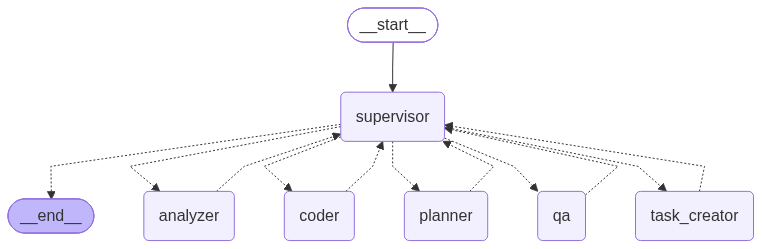

In [103]:
multi_agent_system

## 14. Graph Visualization

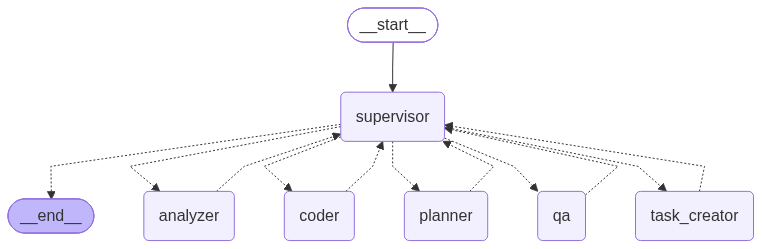

In [99]:
from IPython.display import Image, display

try:
    display(Image(multi_agent_system.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph compiled. (Mermaid PNG render unavailable in current shell environment: ", e, ")")

## 15. Streaming Runner & HITL Continuation Utilities

Provides `run_system()` for streaming tokens/tool calls/node steps, and `resume_system()` for resuming after HITL interrupts.

In [100]:
async def run_system(goal: str, thread_id: str = "session_1"):
    """Stream multi-agent execution events in real time."""
    config = {"configurable": {"thread_id": thread_id}}
    
    initial_state = {
        "messages": [("user", goal)],
        "goal": goal,
        "current_agent": "supervisor",
        "execution_status": "running",
        "execution_history": [],
        "iteration_count": 0,
        "max_iterations": 25,
        "folder_tree": "",
        "analyzer_insights": "",
        "implementation_plan": "",
        "tasks": [],
        "completed_tasks": [],
        "pending_tasks": [],
        "failed_tasks": [],
        "current_task": None,
        "files_changed": [],
        "tool_results": [],
        "qa_report": "",
        "qa_pass": False,
        "error_log": [],
        "retry_count": 0,
        "max_retries": 3,
        "supervisor_reasoning": ""
    }
    
    print(f"🚀 STARTING MULTI-AGENT WORKFLOW [Thread: {thread_id}]")
    print(f"Goal: {goal}\n" + "="*70)
    
    async for event in multi_agent_system.astream_events(initial_state, config=config, version="v2"):
        kind = event["event"]
        node = event.get("metadata", {}).get("langgraph_node", "")
        
        if kind == "on_chain_start" and node:
            print(f"\n▶️ [Node Started]: {node.upper()}")
        elif kind == "on_chat_model_stream" and node:
            chunk = event["data"]["chunk"].content
            if chunk:
                print(chunk, end="", flush=True)
        elif kind == "on_tool_start":
            tool_name = event["name"]
            print(f"\n  🛠️ Executing MCP Tool: {tool_name}...")
        elif kind == "on_tool_end":
            output = str(event["data"].get("output", ""))[:150]
            print(f"  ✅ Tool Output: {output}...")
            
    # Check if interrupted for HITL
    state_snapshot = multi_agent_system.get_state(config)
    if state_snapshot.next:
        print("\n" + "="*70)
        print("🛑 WORKFLOW INTERRUPTED FOR HUMAN APPROVAL!")
        tasks_summary = format_task_summary(state_snapshot.values.get("tasks", []))
        print(f"Tasks Summary:\n{tasks_summary}")
        print("\nCall `await resume_system(thread_id, approved=True)` to continue.")
        
async def resume_system(thread_id: str = "session_1", approved: bool = True, feedback: str = ""):
    """Resume interrupted execution after HITL review."""
    config = {"configurable": {"thread_id": thread_id}}
    decision = {"approved": approved, "feedback": feedback}
    
    print(f"\n▶️ RESUMING WORKFLOW [Thread: {thread_id}] | Approval: {approved}")
    async for event in multi_agent_system.astream_events(Command(resume=decision), config=config, version="v2"):
        kind = event["event"]
        node = event.get("metadata", {}).get("langgraph_node", "")
        if kind == "on_chain_start" and node:
            print(f"\n▶️ [Node Started]: {node.upper()}")
        elif kind == "on_chat_model_stream" and node:
            chunk = event["data"]["chunk"].content
            if chunk:
                print(chunk, end="", flush=True)
        elif kind == "on_tool_start":
            print(f"\n  🛠️ Executing MCP Tool: {event['name']}...")

print("✅ Streaming and HITL runner functions registered.")

✅ Streaming and HITL runner functions registered.


## 16. Interactive System Test & Execution

Run an end-to-end task through the Multi-Agent Coding System.

In [102]:
# Test Goal: Analyze repository structure and summarize workspace status
goal = "Analyze the requirements.txt file and give me report."

# Start streaming execution
await run_system(goal=goal, thread_id="test_run_1")

🚀 STARTING MULTI-AGENT WORKFLOW [Thread: test_run_1]
Goal: Analyze the requirements.txt file and give me report.

▶️ [Node Started]: SUPERVISOR

👑 [Supervisor Agent] Step 1/25 — Orchestrating workflow...
```json
{
  "next_agent": "analyzer",
  "reasoning": "The user goal is to analyze the requirements.txt file, which requires codebase inspection without any code changes or validation."
}
```👑 [Supervisor Agent] Selected Next Agent: 'ANALYZER' | Rationale: The user goal is to analyze the requirements.txt file, which requires codebase inspection without any code changes or validation.


### HITL Approval Resume Cell
Run this cell after reviewing the implementation plan to approve and trigger task execution.

In [ ]:
# Resume execution after approving the plan
await resume_system(thread_id="test_run_1", approved=True)